In [1]:
import sys
sys.path.append("../src")

In [2]:
from Tensorflow.connect_Database import connect
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from preprocessing import clean,stopword
import matplotlib.pyplot as plt
import pickle

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
max_words = 10000
max_len = 80

In [4]:
app =connect()
df = pd.DataFrame(app.load_data_VnExpress())

c:\Users\admin\Data\anaconda\Lib\site-packages\pymongo\pyopenssl_context.py:355: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


In [5]:
def process_texts(texts):
    cleaned = [clean(str(t)) for t in texts]
    processed = stopword(cleaned)
    return processed
df['clean_content'] = process_texts(df['content'])

In [6]:
df = df[df['clean_content'].notna() & (df['clean_content'].str.strip() != '') & df['subtopic'].notna()].reset_index(drop=True)

In [7]:
df = df[
    ~df['subtopic'].isin(['Ảnh']) &
    ~df['topic'].isin(['Xe', 'Thể thao'])
]
counts = df['subtopic'].value_counts()
df = df[df['subtopic'].isin(counts[counts >= 1000].index)]
max_count = 1500
df  = (df.groupby('subtopic', group_keys=False, as_index=False).apply(lambda x: x.sample(max_count, replace=True)).reset_index(drop=True))

C:\Users\admin\AppData\Local\Temp\ipykernel_15304\1275450555.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df  = (df.groupby('subtopic', group_keys=False, as_index=False).apply(lambda x: x.sample(max_count, replace=True)).reset_index(drop=True))


In [8]:
df['subtopic'].value_counts()

subtopic
80 năm Quốc khánh    1500
Thời trang           1500
Phân tích            1500
Quân sự              1500
Quốc tế              1500
Sách                 1500
Sống khỏe            1500
Thiết bị             1500
Thị trường           1500
Tin tức              1500
Nhịp sống            1500
Tư liệu              1500
Tư vấn               1500
Tổ ấm                1500
Vaccine              1500
Vĩ mô                1500
Điểm đến             1500
Đổi mới sáng tạo     1500
Phim                 1500
Nhạc                 1500
AI                   1500
Du học               1500
Bài học sống         1500
Chuyển đổi số        1500
Chính trị            1500
Chứng khoán          1500
Cuộc sống đó đây     1500
Các bệnh             1500
Doanh nghiệp         1500
Ebank                1500
NetZero              1500
Giao thông           1500
Giới sao             1500
Hàng hóa             1500
Hồ sơ phá án      1500
Không gian sống      1500
Kinh tế vùng         1500
Kỷ nguyên mới        1500
Ẩm 

In [9]:
X = df['clean_content'].values  
y_sub = df['subtopic'].values

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(X)

In [10]:
print(tokenizer.word_index) 


{'công': 1, 'thể': 2, 'đồng': 3, 'đầu': 4, 'thành': 5, 'quốc': 6, 'hàng': 7, 'động': 8, 'gia': 9, 'học': 10, 'hiện': 11, 'nam': 12, 'trung': 13, 'trường': 14, 'định': 15, 'phát': 16, 'việt': 17, 'nhân': 18, 'hợp': 19, 'giá': 20, 'thời': 21, 'quan': 22, 'dụng': 23, 'sản': 24, 'nghiệp': 25, 'tế': 26, 'đại': 27, 'triển': 28, 'sinh': 29, 'hành': 30, 'hai': 31, 'trình': 32, 'thông': 33, 'hội': 34, 'thực': 35, 'kết': 36, 'dự': 37, 'năng': 38, 'xuất': 39, 'lý': 40, 'viên': 41, 'cầu': 42, 'doanh': 43, 'hình': 44, 'chủ': 45, 'thị': 46, 'ảnh': 47, 'nghệ': 48, 'tiếp': 49, 'toàn': 50, 'tác': 51, 'mỹ': 52, 'thống': 53, 'lực': 54, 'dân': 55, 'hệ': 56, 'tâm': 57, 'hóa': 58, 'đi': 59, 'kinh': 60, 'đường': 61, 'chức': 62, 'tỷ': 63, 'tài': 64, 'giải': 65, 'độ': 66, 'vụ': 67, '1': 68, 'sĩ': 69, 'tổng': 70, 'gian': 71, 'tiêu': 72, 'giúp': 73, 'khu': 74, 'bệnh': 75, 'giới': 76, 'phòng': 77, 'bảo': 78, 'nội': 79, 'phẩm': 80, '9': 81, 'tập': 82, 'đổi': 83, 'triệu': 84, 'thu': 85, 'điện': 86, '5': 87, '8': 88

In [11]:
from collections import Counter

def counter_word(text_col):
    count = Counter()
    for text in text_col:
        for word in text.split():
            count[word] += 1
    return count

word_count = counter_word(df['clean_content'])


In [12]:
print(word_count.most_common(100))

[('công', 20105), ('thể', 13391), ('đồng', 12848), ('đầu', 12820), ('thành', 11804), ('quốc', 11059), ('hàng', 10664), ('động', 10606), ('gia', 10257), ('học', 10086), ('hiện', 9726), ('nam', 9191), ('trung', 9036), ('trường', 8848), ('định', 8646), ('phát', 8585), ('việt', 8495), ('nhân', 8389), ('hợp', 7988), ('giá', 7653), ('thời', 7472), ('quan', 7390), ('dụng', 7353), ('sản', 7242), ('nghiệp', 7085), ('tế', 7066), ('đại', 7040), ('triển', 7012), ('sinh', 6923), ('hành', 6818), ('hai', 6785), ('trình', 6760), ('thông', 6739), ('hội', 6673), ('thực', 6558), ('kết', 6532), ('dự', 6524), ('năng', 6512), ('xuất', 6292), ('lý', 6242), ('viên', 6119), ('cầu', 6110), ('doanh', 6084), ('hình', 6054), ('chủ', 6041), ('thị', 5967), ('ảnh', 5845), ('nghệ', 5813), ('tiếp', 5750), ('toàn', 5729), ('tác', 5724), ('mỹ', 5633), ('thống', 5607), ('lực', 5457), ('dân', 5453), ('hệ', 5296), ('tâm', 5269), ('hóa', 5217), ('đi', 5214), ('kinh', 5193), ('đường', 5166), ('chức', 5154), ('tỷ', 5046), ('tà

In [13]:
print(tokenizer.word_index.items())

dict_items([('công', 1), ('thể', 2), ('đồng', 3), ('đầu', 4), ('thành', 5), ('quốc', 6), ('hàng', 7), ('động', 8), ('gia', 9), ('học', 10), ('hiện', 11), ('nam', 12), ('trung', 13), ('trường', 14), ('định', 15), ('phát', 16), ('việt', 17), ('nhân', 18), ('hợp', 19), ('giá', 20), ('thời', 21), ('quan', 22), ('dụng', 23), ('sản', 24), ('nghiệp', 25), ('tế', 26), ('đại', 27), ('triển', 28), ('sinh', 29), ('hành', 30), ('hai', 31), ('trình', 32), ('thông', 33), ('hội', 34), ('thực', 35), ('kết', 36), ('dự', 37), ('năng', 38), ('xuất', 39), ('lý', 40), ('viên', 41), ('cầu', 42), ('doanh', 43), ('hình', 44), ('chủ', 45), ('thị', 46), ('ảnh', 47), ('nghệ', 48), ('tiếp', 49), ('toàn', 50), ('tác', 51), ('mỹ', 52), ('thống', 53), ('lực', 54), ('dân', 55), ('hệ', 56), ('tâm', 57), ('hóa', 58), ('đi', 59), ('kinh', 60), ('đường', 61), ('chức', 62), ('tỷ', 63), ('tài', 64), ('giải', 65), ('độ', 66), ('vụ', 67), ('1', 68), ('sĩ', 69), ('tổng', 70), ('gian', 71), ('tiêu', 72), ('giúp', 73), ('khu', 

In [14]:
X_seq = tokenizer.texts_to_sequences(X)

In [15]:
for i in range(10):
    print(f"Text {i}: {X[i][:100]}...")
    print(f"Sequence {i}: {X_seq[i]}")
    print("-"*50)

Text 0: phối hợp địa phương quản lý tĩnh cấm thả bóng bay đèn trời flycam toàn trình luyện tập lễ diễn an to...
Sequence 0: [429, 19, 162, 107, 192, 40, 895, 885, 1552, 861, 225, 995, 536, 6193, 50, 32, 528, 82, 342, 99, 98, 50, 1079, 146, 746, 202, 121, 667, 465, 7, 55, 23]
--------------------------------------------------
Text 1: cụ thể công an tạm cấm ôtô chở hàng khối hàng hóa 3 500 kg trở ôtô chở 29 chỗ trở trừ xe buýt xe thu...
Sequence 1: [348, 2, 1, 98, 811, 885, 812, 1246, 7, 401, 7, 58, 110, 578, 876, 118, 812, 1246, 897, 730, 118, 919, 123, 1715, 123, 85, 1492, 918, 123, 65, 187, 349, 123, 361, 97, 78, 265, 123, 1, 98, 170, 237, 107, 388, 296, 154, 205, 117, 123, 511, 401, 7, 58, 142, 1246, 110, 578, 876, 123, 897, 730, 812, 250, 18, 123, 3427, 111, 8, 61, 40, 421, 14, 850, 345, 850]
--------------------------------------------------
Text 2: động viên khối diễu binh 16 8 trưởng quốc phòng phan văn giang nhấn 2 9 trời mưa đi áo ướt mặt ảnh h...
Sequence 2: [8, 41, 401, 627, 

In [16]:
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating= 'post')

In [17]:
X_pad.shape

(58500, 80)

In [18]:
X_pad[1]

array([ 348,    2,    1,   98,  811,  885,  812, 1246,    7,  401,    7,
         58,  110,  578,  876,  118,  812, 1246,  897,  730,  118,  919,
        123, 1715,  123,   85, 1492,  918,  123,   65,  187,  349,  123,
        361,   97,   78,  265,  123,    1,   98,  170,  237,  107,  388,
        296,  154,  205,  117,  123,  511,  401,    7,   58,  142, 1246,
        110,  578,  876,  123,  897,  730,  812,  250,   18,  123, 3427,
        111,    8,   61,   40,  421,   14,  850,  345,  850,    0,    0,
          0,    0,    0])

In [19]:
word_index = tokenizer.word_index

In [20]:
reverse_word_index = dict([(idx, word) for (word, idx) in word_index.items()])

In [21]:
def decode(sequence):
    return " ".join([reverse_word_index.get(idx, "?") for idx in sequence])

In [22]:
decode_text = decode(X_pad[10])

In [23]:
print(decode_text)

quốc khánh 80 đánh dấu trở bầu trời đình tiêm kích 2 9 1985 ghi dấu ấn đầu tiên phi công quân su 30mk2 yak 130 biểu diễn thả bẫy nhiệt quảng trường trung tâm thủ đô 26 ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?


In [24]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_sub)
y_one_hot = to_categorical(y_encoded)
y_one_hot

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [25]:
print("Original labels:")
print(y_sub)

print("\nLabel encoded:")
print(y_encoded)

print("\nOne-hot encoded:")
print(y_one_hot)

Original labels:
['80 năm Quốc khánh' '80 năm Quốc khánh' '80 năm Quốc khánh' ... 'Ẩm thực'
 'Ẩm thực' 'Ẩm thực']

Label encoded:
[ 0  0  0 ... 38 38 38]

One-hot encoded:
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_one_hot, test_size=0.2, random_state=42
)

In [27]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(y_one_hot.shape[1], activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

c:\Users\admin\Data\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
model_1 = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_one_hot.shape[1], activation='softmax')
])
model_1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [29]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │         2,535 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,375 (5.43 MB)

 Trainable params: 1,422,375 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_1.build(input_shape=(None, max_len))
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 80, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,095 (6.03 MB)

 Trainable params: 1,581,095 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[stopping]
)

Epoch 1/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 71s 92ms/step - accuracy: 0.0268 - loss: 3.6649 - val_accuracy: 0.0251 - val_loss: 3.6621
Epoch 2/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.0277 - loss: 3.6460 - val_accuracy: 0.0621 - val_loss: 3.3201
Epoch 3/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - accuracy: 0.0715 - loss: 3.2455 - val_accuracy: 0.1271 - val_loss: 2.8484
Epoch 4/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 76s 103ms/step - accuracy: 0.1405 - loss: 2.7857 - val_accuracy: 0.2799 - val_loss: 2.3716
Epoch 5/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 70s 95ms/step - accuracy: 0.2687 - loss: 2.3224 - val_accuracy: 0.3814 - val_loss: 2.0021
Epoch 6/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 76s 104ms/step - accuracy: 0.3892 - loss: 1.9255 - val_accuracy: 0.4615 - val_loss: 1.7281
Epoch 7/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.4767 - loss: 1.6350 - val_accuracy: 0.5277 - val_loss: 1.5862
Epoch 8/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.5456 - loss: 1.443

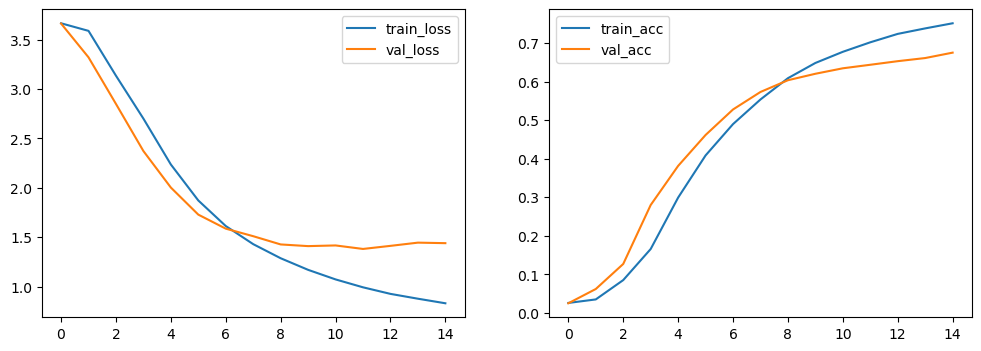

In [32]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [33]:
history_1 = model_1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[stopping]
)

Epoch 1/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 355s 475ms/step - accuracy: 0.1170 - loss: 3.1936 - val_accuracy: 0.4227 - val_loss: 1.9140
Epoch 2/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 369s 503ms/step - accuracy: 0.4211 - loss: 1.9040 - val_accuracy: 0.5250 - val_loss: 1.5749
Epoch 3/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 378s 517ms/step - accuracy: 0.5389 - loss: 1.5100 - val_accuracy: 0.5721 - val_loss: 1.4205
Epoch 4/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 369s 504ms/step - accuracy: 0.6082 - loss: 1.2989 - val_accuracy: 0.6037 - val_loss: 1.3272
Epoch 5/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 389s 531ms/step - accuracy: 0.6567 - loss: 1.1389 - val_accuracy: 0.6291 - val_loss: 1.2886
Epoch 6/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 409s 559ms/step - accuracy: 0.6948 - loss: 1.0072 - val_accuracy: 0.6487 - val_loss: 1.2338
Epoch 7/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 392s 536ms/step - accuracy: 0.7216 - loss: 0.9184 - val_accuracy: 0.6685 - val_loss: 1.2025
Epoch 8/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 401s 547ms/step - accuracy: 0.7550 -

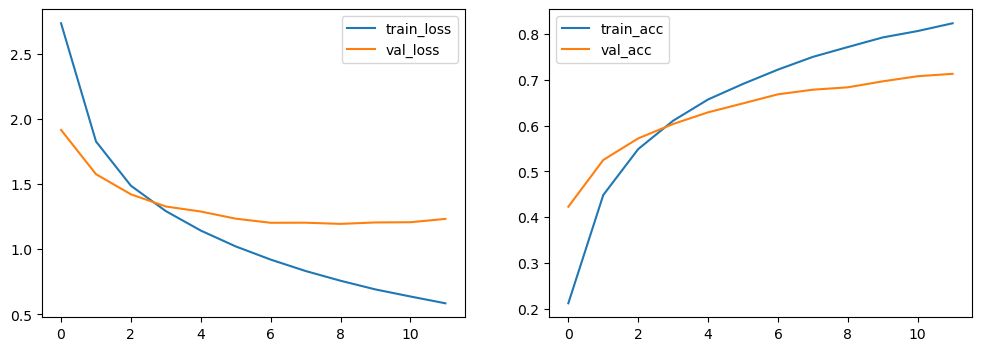

In [34]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_1.history['loss'], label='train_loss')
plt.plot(history_1.history['val_loss'], label='val_loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_1.history['accuracy'], label='train_acc')
plt.plot(history_1.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [35]:
model.save_weights("../models/Tensorflow/models.weights.h5")
with open("../models/Tensorflow/tokenizers.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("../models/Tensorflow/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [36]:
model_1.save_weights("../models/Tensorflow/models_1.weights.h5")

In [37]:
model.load_weights("../models/Tensorflow/models.weights.h5")
model_1.load_weights("../models/Tensorflow/models_1.weights.h5")
tokenizer = pickle.load(open("../models/Tensorflow/tokenizers.pkl", "rb"))
label_encoder = pickle.load(open("../models/Tensorflow/label_encoder.pkl", "rb"))

In [38]:
df_Reddit = pd.DataFrame(app.load_data())

In [39]:
df_Reddit['clean_content'] = process_texts(df_Reddit['content'])
df_result = df_Reddit.dropna(subset=['clean_content']).reset_index(drop=True)
df_Reddit = df_Reddit[
    df_Reddit['clean_content'].notna() &
    (df_Reddit['clean_content'].str.strip() != "") &
    (df_Reddit['clean_content'].str.lower() != "none")
].reset_index(drop=True)
contents = df_Reddit['clean_content'].dropna().tolist()


In [40]:
X_new = tokenizer.texts_to_sequences(contents)
X_new = pad_sequences(X_new, maxlen=max_len, padding='post', truncating='post')

predictions  = model.predict(X_new)
categories = label_encoder.inverse_transform(predictions .argmax(axis=1))

430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step


In [41]:
df_Reddit['label'] =categories

In [42]:
print(contents[130])
print(X_new[130])

mấy hot gpt genemi claude grok bọn tàu dịch sượng voz vn mấy kia toàn seeder mấy mấy dịch tệ bọn mục đích dốt tiếng 1 kênh yt tiếng đọc sub ko nghĩa kiếm ai chất dịch
[1938 2530 2527 3503 4934 3863  514  103 1001 1938 1789   50 1938 1938
  103  917 3863  184 1034  194   68 1045  194  800 7046  419  663  105
  116  103    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [43]:
check = tokenizer.index_word.get(2556 , None)
check

'nón'

In [44]:
df_Reddit.head(5)

,link,author,comments,content,date,image_link,subreddit,title,upvotes,video_link,clean_content,label
0,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Friendly-Lie5849,37,Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoa...,2025-08-22 07:25:50,None,TroChuyenLinhTinh,Những gì đang diễn ra ở Trung Quốc đang dần lặ...,157,None,phim tuyên truyền chủ nghĩa dân tộc cực đoan m...,Phim
1,https://www.reddit.com/r/vozforums/comments/1m...,TinNT0409,1,"Chào mọi người, đợt này mình có dùng Mathpix đ...",2025-08-22 07:23:33,https://external-preview.redd.it/kqhxR96oyl5gx...,vozforums,Phần mềm quét công thức sang Word miễn phí tha...,2,None,chào đợt mathpix quét công thức đc 10 lượt viế...,Tư vấn
2,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Weekly_Top7078,3,Trước kì kinh bao nhiêu ngày thì an toàn?,2025-08-22 07:07:46,None,TroChuyenLinhTinh,Ngày an toàn,0,None,kì kinh bao nhiêu an toàn,Không gian sống
3,https://www.reddit.com/r/VietNamNation/comment...,Ambitious-Fan-9831,18,ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi...,2025-08-22 07:04:09,None,VietNamNation,Thái Lan có phải là 1 hình mẫu nước đáng sống ...,16,None,ờm tỉ lệ gái đẹp tao bề nổi thái lọ cánh tả số...,Cuộc sống đó đây
4,https://www.reddit.com/r/vozforums/comments/1m...,Nicklas0704,3,"Hi các bác, e làm mmo có dư 1 ít, cụ thể là kh...",2025-08-22 14:03:21,None,vozforums,Hiện tại nên bỏ tiền vào đâu ?,0,None,hi e mmo dư 1 cụ thể 10 tỉ tham gia đầu hiện e...,Chứng khoán


In [45]:
for idx, row in df_Reddit.head(500).iterrows():
    print(f"Author: {row['author']}")
    print(f"subreddit: {row['subreddit']}")
    print(f"Content: {row['content'][:200]}...")
    print(f"Label: {row['label']}")
    print("-"*60)

Author: Friendly-Lie5849
subreddit: TroChuyenLinhTinh
Content: Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoan Mưa Đỏ aka Máu Kinh đang được truyền thông, dư luận viên, bò đỏ, Sô-Vanh con tung hê hết lời. Phim hiện đã thu về 28 tỷ đồng vào ngày đầu công chiếu là ...
Label: Phim
------------------------------------------------------------
Author: TinNT0409
subreddit: vozforums
Content: Chào mọi người, đợt này mình có dùng Mathpix để quét công thức nhưng đc có 10 lượt nên Viết luôn app thay thế miễn phí [AuraLateX](https://auravsoftware.com/chuyen-cong-thuc-toan-sang-word/)...
Label: Tư vấn
------------------------------------------------------------
Author: Weekly_Top7078
subreddit: TroChuyenLinhTinh
Content: Trước kì kinh bao nhiêu ngày thì an toàn?...
Label: Không gian sống
------------------------------------------------------------
Author: Ambitious-Fan-9831
subreddit: VietNamNation
Content: ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi của Thái lọ có nhiều cái khá cánh tả đáng để 

In [46]:
df_Reddit[df_Reddit['label'] == "AI"]


,link,author,comments,content,date,image_link,subreddit,title,upvotes,video_link,clean_content,label
10,https://www.reddit.com/r/vozforums/comments/1m...,Ok-Mix-1952,27,Tôi một sinh viên CNTT mới ra trường mảng lập ...,2025-08-22 05:30:48,None,vozforums,"Rời Hà Nội vì không tìm được việc, về KCN làm ...",10,None,sinh viên cntt trường mảng lập trình di động n...,AI
54,https://www.reddit.com/r/vozforums/comments/1m...,One-Preparation7056,7,"Chào mng ạ , em 2k7 chuẩn bị bước chân vào đại...",2025-08-21 20:21:35,None,vozforums,Nên sử dụng AI cho đại học trong ngành cntt ?,1,None,chào mng 2k7 chuẩn chân đại học ngành hệ thống...,AI
124,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Safe-Rush6558,3,1. Tại sao công ty không tự tuyển luôn mà phải...,2025-08-21 14:51:33,None,TroChuyenLinhTinh,Công ty cung ứng lao động là gì?,3,None,1 công ty tuyển đi dịch vụ cung ứng 2 cung ứng...,AI
130,https://www.reddit.com/r/vozforums/comments/1m...,Flat-Entry-8735,10,"mấy bác cho em vài cái tên với ạ , em đã dùng ...",2025-08-21 13:48:10,None,vozforums,AI nào dịch tốt nhất hiện nay,4,None,mấy hot gpt genemi claude grok bọn tàu dịch sư...,AI
138,https://www.reddit.com/r/vozforums/comments/1m...,Standard-Bar-5681,0,Thời gian thi công nhanh chóng là một đặc điểm...,2025-08-21 12:42:14,https://external-preview.redd.it/TS82R0mQ8I11N...,vozforums,Xử lý nước thải rửa xe tại Bình Dương chi ...,3,None,thời gian thi công chóng đặc lợi công ty công ...,AI
...,...,...,...,...,...,...,...,...,...,...,...,...
13632,https://www.reddit.com/r/VietNamNation/comment...,Chunghiacanhanvidai,0,"Tao nhớ hồi đầu năm 2025, mấy thằng cuồng Tây ...",2025-11-20 04:28:02,None,VietNamNation,Ký ức về AI đầu năm 2025.,0,None,tao hồi đầu 2025 mấy thằng cuồng tây chế giễu ...,AI
13678,https://www.reddit.com/r/vozforums/comments/1p...,kerfsrt,2,"Có ai có ký ức gì với hình học 8, 9 ko ạ. Em d...",2025-11-20 08:55:44,None,vozforums,"Hình học lớp 8, 9",3,None,ai ký ức hình học 8 9 ko dạy trai hình chán nả...,AI
13688,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Own_Distribution9658,32,Nếu mà tụi mày bị lũ bỏ đỏ phải tk mxh của tụi...,2025-11-20 07:05:46,None,TroChuyenLinhTinh,Nếu mà tao bị lũ bỏ đỏ phát hiện tk mxh là của...,7,None,tụi mày lũ đỏ tk mxh tụi mày tụi mày chia sẻ t...,AI
13691,https://www.reddit.com/r/VietNamNation/comment...,Own_Distribution9658,3,Tụi mày chia sẻ đi nếu mà tao bị bỏ đỏ biết tk...,2025-11-20 06:54:14,None,VietNamNation,Ê tụi mày nếu mà tao bị tụi bỏ đỏ biết tk là t...,4,None,tụi mày chia sẻ đi tao đỏ tk tao xoá chứng,AI


In [47]:
X_new = tokenizer.texts_to_sequences(contents)
X_new = pad_sequences(X_new, maxlen=max_len, padding='post', truncating='post')

predictions  = model_1.predict(X_new)
categories = label_encoder.inverse_transform(predictions .argmax(axis=1))

430/430 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step


In [48]:
df_Reddit['label'] =categories

In [49]:
print(contents[130])
print(X_new[130])

mấy hot gpt genemi claude grok bọn tàu dịch sượng voz vn mấy kia toàn seeder mấy mấy dịch tệ bọn mục đích dốt tiếng 1 kênh yt tiếng đọc sub ko nghĩa kiếm ai chất dịch
[1938 2530 2527 3503 4934 3863  514  103 1001 1938 1789   50 1938 1938
  103  917 3863  184 1034  194   68 1045  194  800 7046  419  663  105
  116  103    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [50]:
check = tokenizer.index_word.get(2556 , None)
check

'nón'

In [51]:
df_Reddit.head(5)

,link,author,comments,content,date,image_link,subreddit,title,upvotes,video_link,clean_content,label
0,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Friendly-Lie5849,37,Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoa...,2025-08-22 07:25:50,None,TroChuyenLinhTinh,Những gì đang diễn ra ở Trung Quốc đang dần lặ...,157,None,phim tuyên truyền chủ nghĩa dân tộc cực đoan m...,Phim
1,https://www.reddit.com/r/vozforums/comments/1m...,TinNT0409,1,"Chào mọi người, đợt này mình có dùng Mathpix đ...",2025-08-22 07:23:33,https://external-preview.redd.it/kqhxR96oyl5gx...,vozforums,Phần mềm quét công thức sang Word miễn phí tha...,2,None,chào đợt mathpix quét công thức đc 10 lượt viế...,Tư vấn
2,https://www.reddit.com/r/TroChuyenLinhTinh/com...,Weekly_Top7078,3,Trước kì kinh bao nhiêu ngày thì an toàn?,2025-08-22 07:07:46,None,TroChuyenLinhTinh,Ngày an toàn,0,None,kì kinh bao nhiêu an toàn,Nhịp sống
3,https://www.reddit.com/r/VietNamNation/comment...,Ambitious-Fan-9831,18,ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi...,2025-08-22 07:04:09,None,VietNamNation,Thái Lan có phải là 1 hình mẫu nước đáng sống ...,16,None,ờm tỉ lệ gái đẹp tao bề nổi thái lọ cánh tả số...,Tổ ấm
4,https://www.reddit.com/r/vozforums/comments/1m...,Nicklas0704,3,"Hi các bác, e làm mmo có dư 1 ít, cụ thể là kh...",2025-08-22 14:03:21,None,vozforums,Hiện tại nên bỏ tiền vào đâu ?,0,None,hi e mmo dư 1 cụ thể 10 tỉ tham gia đầu hiện e...,Hàng hóa


In [52]:
for idx, row in df_Reddit.head(500).iterrows():
    print(f"Author: {row['author']}")
    print(f"subreddit: {row['subreddit']}")
    print(f"Content: {row['content'][:200]}...")
    print(f"Label: {row['label']}")
    print("-"*60)

Author: Friendly-Lie5849
subreddit: TroChuyenLinhTinh
Content: Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoan Mưa Đỏ aka Máu Kinh đang được truyền thông, dư luận viên, bò đỏ, Sô-Vanh con tung hê hết lời. Phim hiện đã thu về 28 tỷ đồng vào ngày đầu công chiếu là ...
Label: Phim
------------------------------------------------------------
Author: TinNT0409
subreddit: vozforums
Content: Chào mọi người, đợt này mình có dùng Mathpix để quét công thức nhưng đc có 10 lượt nên Viết luôn app thay thế miễn phí [AuraLateX](https://auravsoftware.com/chuyen-cong-thuc-toan-sang-word/)...
Label: Tư vấn
------------------------------------------------------------
Author: Weekly_Top7078
subreddit: TroChuyenLinhTinh
Content: Trước kì kinh bao nhiêu ngày thì an toàn?...
Label: Nhịp sống
------------------------------------------------------------
Author: Ambitious-Fan-9831
subreddit: VietNamNation
Content: ờm bỏ qua tỉ lệ gái đẹp ra thì tao thấy bề nổi của Thái lọ có nhiều cái khá cánh tả đáng để sống.


In [56]:
df_Reddit['label'].value_counts()

label
Bài học sống         1296
Sách                  970
Tổ ấm                 847
Cuộc sống đó đây      720
Nhịp sống             626
Giới sao              608
Tư liệu               604
Tin tức               505
Hồ sơ phá án       474
Phim                  467
Du học                460
Doanh nghiệp          459
80 năm Quốc khánh     434
AI                    418
Tư vấn                417
Điểm đến              390
Chuyển đổi số         378
Thiết bị              350
Hàng hóa              331
Ẩm thực               281
Quốc tế               273
Phân tích             273
Sống khỏe             245
Chính trị             244
Các bệnh              187
Nhạc                  183
Quân sự               180
Thời trang            175
Ebank                 141
Kinh tế vùng          113
Đổi mới sáng tạo      103
Vĩ mô                  97
Giao thông             95
Kỷ nguyên mới          90
Không gian sống        70
Chứng khoán            69
NetZero                65
Thị trường             53
Vaccin